In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])

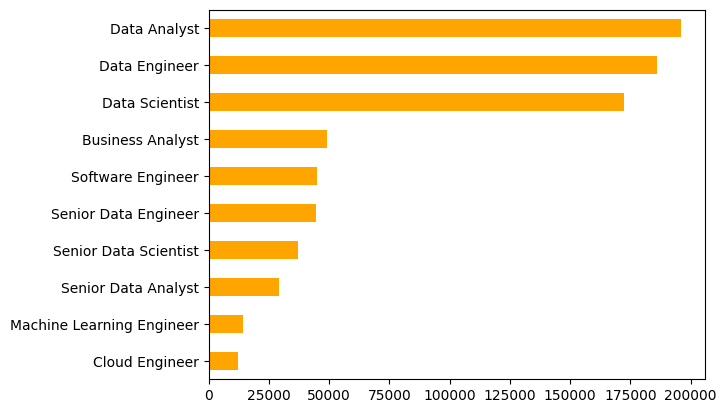

In [52]:
# plotting a series

job_count = df["job_title_short"].value_counts().sort_values(ascending=True)
job_count.plot(kind="barh", color="orange")
plt.ylabel("")
plt.show()

In [ ]:
# plotting a dataframe

df["job_posted_month"] = df["job_posted_date"].dt.month

filtered_df = df.loc[
    df["salary_year_avg"].notna(),
    ["job_posted_month", "salary_year_avg"]
]

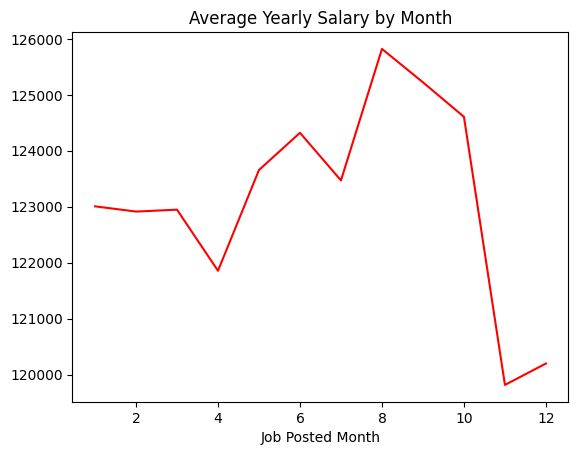

In [50]:
agg_df = filtered_df.groupby("job_posted_month").agg(
    avg_yearly_salary=("salary_year_avg", "mean")
).round(2).reset_index()

agg_df
agg_df.plot(x="job_posted_month", y="avg_yearly_salary", kind="line", color="red")
plt.title("Average Yearly Salary by Month")
plt.xlabel("Job Posted Month")
plt.legend().set_visible(False)
plt.show()